# Customer Segmentation Analysis
### Data Analytics Internship — Task 2
**Kinetrexa Software Pvt. Ltd.**

This notebook segments customers using demographic and behavioral data (RFM analysis) to identify
valuable customer groups for targeted marketing strategies.

**Sections**
1. Data Loading & Cleaning
2. Merge Customer + Order Data
3. RFM Feature Engineering (Recency, Frequency, Monetary)
4. RFM Scoring & Segmentation
5. K-Means Clustering (data-driven segments)
6. Segment Profiling & Visualization
7. Business Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Data Loading & Cleaning

In [2]:
orders = pd.read_csv("../data/sales_data.csv", parse_dates=["order_date"])
customers = pd.read_csv("../data/customers.csv")

orders = orders.drop_duplicates()
orders["discount_pct"] = orders["discount_pct"].fillna(0)
orders["customer_rating"] = orders["customer_rating"].fillna(orders["customer_rating"].median())
orders["is_returned"] = orders["is_returned"].astype(bool)

orders_valid = orders[~orders["is_returned"]].copy()
print("Orders (valid):", orders_valid.shape)
print("Customers:", customers.shape)
customers.head()


Orders (valid): (5755, 17)
Customers: (850, 7)


,customer_id,customer_name,region,age,gender,acquisition_channel,city
0,CUST0001,Nisha Desai,South,28,Male,Social Media,Chennai
1,CUST0002,Ramesh Kapoor,East,32,Female,Email Campaign,Patna
2,CUST0003,Krishna Gupta,South,36,Male,Organic Search,Bengaluru
3,CUST0004,Tara Menon,North,24,Male,Organic Search,Chandigarh
4,CUST0005,Ananya Nair,East,45,Female,Organic Search,Bhubaneswar


## 2. Merge Customer + Order Data

In [3]:
data = orders_valid.merge(customers, on=["customer_id", "customer_name", "region", "city"], how="left")
data.head()


,order_id,order_date,customer_id,customer_name,region,city,category,product_name,unit_price,quantity,discount_pct,gross_amount,discount_amount,net_amount,payment_method,is_returned,customer_rating,age,gender,acquisition_channel
0,ORD103769,2024-08-01,CUST0680,Manisha Chopra,East,Guwahati,Beauty & Personal Care,Hair Dryer,640.82,1,0.0,640.82,0.00,640.82,Credit Card,False,5.0,19,Male,Referral
1,ORD105393,2024-08-01,CUST0406,Vikram Rao,North,Lucknow,Sports & Fitness,Cycling Helmet,849.11,1,5.0,849.11,42.46,806.65,UPI,False,2.0,56,Male,Referral
2,ORD103626,2024-08-01,CUST0406,Vikram Rao,North,Lucknow,Home & Kitchen,Mixer Grinder,7927.31,1,0.0,7927.31,0.00,7927.31,Credit Card,False,5.0,56,Male,Referral
3,ORD103451,2024-08-01,CUST0478,Arjun Kapoor,South,Chennai,Fashion,Sunglasses,5663.99,1,0.0,5663.99,0.00,5663.99,Credit Card,False,4.0,42,Male,Organic Search
4,ORD100631,2024-08-01,CUST0578,Kiran Patel,North,Chandigarh,Home & Kitchen,Vacuum Cleaner,3017.17,1,0.0,3017.17,0.00,3017.17,Debit Card,False,4.0,42,Female,Referral


## 3. RFM Feature Engineering

- **Recency** — days since the customer's most recent order (lower = more recently active)
- **Frequency** — number of distinct orders placed
- **Monetary** — total net amount spent


In [4]:
snapshot_date = orders_valid["order_date"].max() + pd.Timedelta(days=1)

rfm = data.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("net_amount", "sum"),
).reset_index()

rfm = rfm.merge(customers[["customer_id", "customer_name", "region", "city", "age", "gender",
                            "acquisition_channel"]], on="customer_id", how="left")
rfm.describe()


,recency,frequency,monetary,age
count,777.000000,777.000000,777.000000,777.000000
mean,163.850708,7.406692,76267.721634,41.410553
std,159.462890,6.910649,82616.083543,13.448548
min,1.000000,1.000000,296.320000,18.000000
25%,44.000000,2.000000,16843.310000,30.000000
50%,109.000000,5.000000,50998.290000,41.000000
75%,233.000000,10.000000,104287.180000,53.000000
max,728.000000,45.000000,639425.310000,64.000000


## 4. RFM Scoring & Rule-Based Segmentation

In [5]:
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def label_segment(row):
    if row["RFM_score"] >= 10:
        return "Champions"
    elif row["RFM_score"] >= 8:
        return "Loyal Customers"
    elif row["RFM_score"] >= 6:
        return "Potential Loyalists"
    elif row["RFM_score"] >= 4:
        return "At Risk"
    else:
        return "Lost / Dormant"

rfm["rfm_segment"] = rfm.apply(label_segment, axis=1)
rfm["rfm_segment"].value_counts()


rfm_segment
Champions              238
Loyal Customers        155
At Risk                148
Potential Loyalists    147
Lost / Dormant          89
Name: count, dtype: int64

In [6]:
fig = px.pie(rfm, names="rfm_segment", title="Customer Segments (RFM Rule-Based)", hole=0.4)
fig.show()


## 5. K-Means Clustering (Data-Driven Segments)

C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



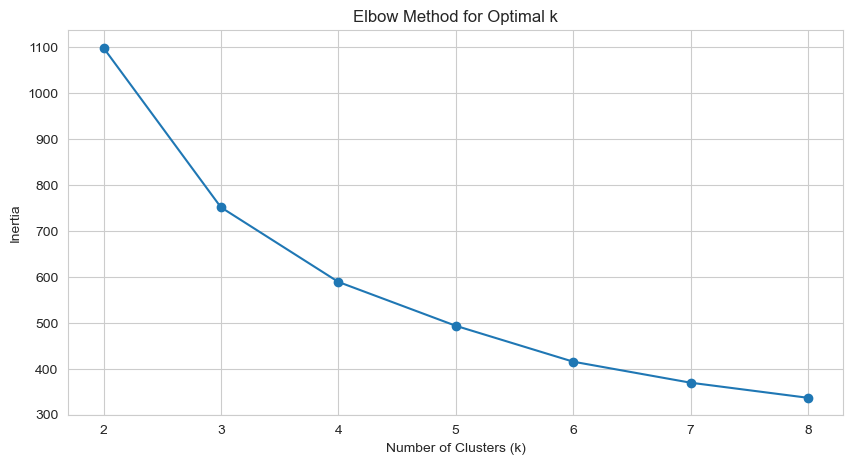

In [7]:
features = rfm[["recency", "frequency", "monetary"]].copy()
# log-transform monetary/frequency to reduce skew, then scale
features["monetary"] = np.log1p(features["monetary"])
features["frequency"] = np.log1p(features["frequency"])

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Elbow method to choose k
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [8]:
# k=4 chosen from elbow curve
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(scaled)

cluster_summary = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean().round(1)
cluster_summary["customers"] = rfm["cluster"].value_counts().sort_index()
cluster_summary


C:\Users\sivap\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



,recency,frequency,monetary,customers
cluster,,,,
0,193.8,2.2,11982.4,160
1,56.8,15.3,164487.6,242
2,125.9,5.5,56380.9,284
3,514.0,1.6,16754.6,91


In [9]:
# Name clusters based on their RFM profile
cluster_order = cluster_summary.sort_values("monetary", ascending=False).index.tolist()
cluster_names = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk"]
name_map = dict(zip(cluster_order, cluster_names[:len(cluster_order)]))
rfm["cluster_segment"] = rfm["cluster"].map(name_map)
rfm["cluster_segment"].value_counts()


cluster_segment
Loyal Customers        284
Champions              242
At Risk                160
Potential Loyalists     91
Name: count, dtype: int64

## 6. Segment Profiling & Visualization

In [10]:
fig = px.scatter_3d(rfm, x="recency", y="frequency", z="monetary", color="cluster_segment",
                     title="Customer Segments — RFM 3D View", opacity=0.7)
fig.show()


In [11]:
fig = px.box(rfm, x="cluster_segment", y="monetary", color="cluster_segment",
             title="Monetary Value Distribution by Segment")
fig.show()


In [12]:
region_segment = pd.crosstab(rfm["region"], rfm["cluster_segment"])
fig = px.bar(region_segment, barmode="stack", title="Segment Distribution by Region")
fig.show()


In [13]:
segment_profile = rfm.groupby("cluster_segment").agg(
    customers=("customer_id", "count"),
    avg_recency_days=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
).round(1).sort_values("total_revenue", ascending=False)
segment_profile


,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue
cluster_segment,,,,,
Champions,242,56.8,15.3,164487.6,39806010.2
Loyal Customers,284,125.9,5.5,56380.9,16012161.7
At Risk,160,193.8,2.2,11982.4,1917176.4
Potential Loyalists,91,514.0,1.6,16754.6,1524671.4


## 7. Business Recommendations

In [14]:
top_segment = segment_profile.index[0]
top_segment_rev_share = (segment_profile.loc[top_segment, "total_revenue"] / segment_profile["total_revenue"].sum()) * 100

print(f"""
KEY INSIGHTS
------------
1. '{top_segment}' is the highest-value segment, contributing {top_segment_rev_share:.1f}% of total revenue
   from just {segment_profile.loc[top_segment, "customers"]} customers.
2. Segments with high recency (long time since last order) represent churn risk and should be re-engaged.
3. High-frequency, high-monetary customers are strong candidates for a loyalty/VIP program.
4. Regional distribution of segments highlights where premium campaigns will have the most impact.

RECOMMENDATIONS
----------------
- Champions: reward with early access, exclusive discounts, and referral incentives to maximize lifetime value.
- Loyal Customers: upsell complementary categories and encourage subscription/repeat-purchase plans.
- Potential Loyalists: nurture with personalized recommendations and second-purchase incentives.
- At Risk / Lost: launch win-back campaigns (limited-time discounts, reminder emails) before they churn fully.
- Use acquisition_channel data to identify which channels bring in the highest-LTV customers and reallocate budget.
""")



KEY INSIGHTS
------------
1. 'Champions' is the highest-value segment, contributing 67.2% of total revenue
   from just 242 customers.
2. Segments with high recency (long time since last order) represent churn risk and should be re-engaged.
3. High-frequency, high-monetary customers are strong candidates for a loyalty/VIP program.
4. Regional distribution of segments highlights where premium campaigns will have the most impact.

RECOMMENDATIONS
----------------
- Champions: reward with early access, exclusive discounts, and referral incentives to maximize lifetime value.
- Loyal Customers: upsell complementary categories and encourage subscription/repeat-purchase plans.
- Potential Loyalists: nurture with personalized recommendations and second-purchase incentives.
- At Risk / Lost: launch win-back campaigns (limited-time discounts, reminder emails) before they churn fully.
- Use acquisition_channel data to identify which channels bring in the highest-LTV customers and reallocate budg

In [15]:
rfm.to_csv("../reports/customer_segments.csv", index=False)
segment_profile.to_csv("../reports/segment_profile.csv")
print("Exported customer_segments.csv and segment_profile.csv to ../reports/")


Exported customer_segments.csv and segment_profile.csv to ../reports/
